In [101]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns

In [102]:
from sklearn.model_selection import train_test_split

from sklearn.preprocessing import LabelEncoder

from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay


In [103]:
import joblib

In [104]:
import warnings
warnings.filterwarnings("ignore")

In [105]:
df=pd.read_csv("smart hospital.csv")
df

,patient_id,age,gender,city,bmi,chronic_disease,appointment_type,department,symptoms,severity_level,...,waiting_time_minutes,previous_appointments,missed_previous_appointments,hospital_rating,emergency_case,patient_satisfaction_score,medicine_cost,test_cost,total_bill,appointment_status
0,PAT_10000,52,Male,Mumbai,19.6,Hypertension,Scheduled,Neurology,Headache,Low,...,43,7,2,3.0,0,8.6,869,413,1936.0,Completed
1,PAT_10001,21,Female,Mumbai,25.3,NaN,Scheduled,Neurology,Headache,Low,...,44,11,5,3.5,0,8.8,786,875,1356.6,No Show
2,PAT_10002,51,Female,Bangalore,21.9,NaN,Scheduled,Dermatology,Skin Allergy,Low,...,33,9,0,4.4,0,10.0,466,427,1108.8,No Show
3,PAT_10003,78,Female,Delhi,31.7,NaN,Walk-in,Orthopedics,Joint Pain,Low,...,59,13,3,4.1,0,8.1,921,401,1417.5,Completed
4,PAT_10004,62,Female,Mumbai,24.7,Hypertension,Scheduled,Ophthalmology,Eye Irritation,Low,...,42,4,0,3.5,0,8.9,152,216,746.9,Completed
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,PAT_19995,15,Male,Nagpur,17.2,NaN,Walk-in,Neurology,Headache,High,...,8,5,1,4.8,0,10.0,7218,11425,13643.0,Completed
9996,PAT_19996,70,Female,Pune,36.3,NaN,Walk-in,Cardiology,Chest Pain,Medium,...,19,0,0,3.1,0,10.0,4671,3558,6234.9,Completed
9997,PAT_19997,64,Female,Kolkata,27.3,Diabetes,Emergency,Ophthalmology,Eye Irritation,Low,...,47,8,3,4.6,1,9.2,189,276,879.0,Completed
9998,PAT_19998,21,Male,Hyderabad,27.0,Hypertension,Walk-in,Gastroenterology,Stomach Pain,High,...,12,11,7,3.1,0,10.0,8044,7855,11531.1,Completed


In [106]:
print("Rows :",df.shape[0])
print("Columns :",df.shape[1])

Rows : 10000
Columns : 26


In [107]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 26 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   patient_id                    10000 non-null  object 
 1   age                           10000 non-null  int64  
 2   gender                        10000 non-null  object 
 3   city                          10000 non-null  object 
 4   bmi                           10000 non-null  float64
 5   chronic_disease               5550 non-null   object 
 6   appointment_type              10000 non-null  object 
 7   department                    10000 non-null  object 
 8   symptoms                      10000 non-null  object 
 9   severity_level                10000 non-null  object 
 10  doctor_experience_years       10000 non-null  int64  
 11  consultation_fee              10000 non-null  int64  
 12  insurance                     10000 non-null  object 
 13  ap

In [108]:
df.columns

Index(['patient_id', 'age', 'gender', 'city', 'bmi', 'chronic_disease',
       'appointment_type', 'department', 'symptoms', 'severity_level',
       'doctor_experience_years', 'consultation_fee', 'insurance',
       'appointment_day', 'appointment_month', 'booking_to_appointment_days',
       'waiting_time_minutes', 'previous_appointments',
       'missed_previous_appointments', 'hospital_rating', 'emergency_case',
       'patient_satisfaction_score', 'medicine_cost', 'test_cost',
       'total_bill', 'appointment_status'],
      dtype='object')

In [109]:
df.dtypes

patient_id                       object
age                               int64
gender                           object
city                             object
bmi                             float64
chronic_disease                  object
appointment_type                 object
department                       object
symptoms                         object
severity_level                   object
doctor_experience_years           int64
consultation_fee                  int64
insurance                        object
appointment_day                  object
appointment_month                object
booking_to_appointment_days       int64
waiting_time_minutes              int64
previous_appointments             int64
missed_previous_appointments      int64
hospital_rating                 float64
emergency_case                    int64
patient_satisfaction_score      float64
medicine_cost                     int64
test_cost                         int64
total_bill                      float64


In [110]:
df.describe()

,age,bmi,doctor_experience_years,consultation_fee,booking_to_appointment_days,waiting_time_minutes,previous_appointments,missed_previous_appointments,hospital_rating,emergency_case,patient_satisfaction_score,medicine_cost,test_cost,total_bill
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,45.000400,24.010890,15.399000,606.860700,12.754500,25.203900,7.019200,1.416700,3.989940,0.148600,9.701980,5053.976100,3932.363100,7881.768000
std,25.862836,3.935325,8.604069,180.246694,9.405715,14.862961,4.334502,1.383637,0.579424,0.355712,0.537897,5618.208887,4165.875586,7904.071155
min,1.000000,15.000000,1.000000,220.000000,0.000000,1.000000,0.000000,0.000000,3.000000,0.000000,7.600000,100.000000,0.000000,331.800000
25%,22.000000,21.300000,8.000000,461.000000,4.000000,13.000000,3.000000,0.000000,3.500000,0.000000,9.600000,758.750000,748.000000,1598.100000
50%,45.000000,24.000000,15.000000,609.000000,12.000000,23.000000,7.000000,1.000000,4.000000,0.000000,10.000000,2833.000000,2345.000000,4631.550000
75%,68.000000,26.700000,23.000000,752.000000,21.000000,35.000000,11.000000,2.000000,4.500000,0.000000,10.000000,7499.500000,5817.500000,13280.000000
max,89.000000,39.800000,30.000000,999.000000,29.000000,59.000000,14.000000,9.000000,5.000000,1.000000,10.000000,19996.000000,14992.000000,34894.000000


In [111]:
df.isna().sum()

patient_id                         0
age                                0
gender                             0
city                               0
bmi                                0
chronic_disease                 4450
appointment_type                   0
department                         0
symptoms                           0
severity_level                     0
doctor_experience_years            0
consultation_fee                   0
insurance                          0
appointment_day                    0
appointment_month                  0
booking_to_appointment_days        0
waiting_time_minutes               0
previous_appointments              0
missed_previous_appointments       0
hospital_rating                    0
emergency_case                     0
patient_satisfaction_score         0
medicine_cost                      0
test_cost                          0
total_bill                         0
appointment_status                 0
dtype: int64

In [112]:
(df.isnull().sum()/len(df))*100

patient_id                       0.0
age                              0.0
gender                           0.0
city                             0.0
bmi                              0.0
chronic_disease                 44.5
appointment_type                 0.0
department                       0.0
symptoms                         0.0
severity_level                   0.0
doctor_experience_years          0.0
consultation_fee                 0.0
insurance                        0.0
appointment_day                  0.0
appointment_month                0.0
booking_to_appointment_days      0.0
waiting_time_minutes             0.0
previous_appointments            0.0
missed_previous_appointments     0.0
hospital_rating                  0.0
emergency_case                   0.0
patient_satisfaction_score       0.0
medicine_cost                    0.0
test_cost                        0.0
total_bill                       0.0
appointment_status               0.0
dtype: float64

In [113]:
mode_value = df["chronic_disease"].mode()[0]

df["chronic_disease"] = df["chronic_disease"].fillna(mode_value)

In [114]:
df.isna().sum()

patient_id                      0
age                             0
gender                          0
city                            0
bmi                             0
chronic_disease                 0
appointment_type                0
department                      0
symptoms                        0
severity_level                  0
doctor_experience_years         0
consultation_fee                0
insurance                       0
appointment_day                 0
appointment_month               0
booking_to_appointment_days     0
waiting_time_minutes            0
previous_appointments           0
missed_previous_appointments    0
hospital_rating                 0
emergency_case                  0
patient_satisfaction_score      0
medicine_cost                   0
test_cost                       0
total_bill                      0
appointment_status              0
dtype: int64

In [115]:
print("Duplicate Rows =",df.duplicated().sum())

Duplicate Rows = 0


In [116]:
df=df.drop_duplicates()

In [117]:
df["appointment_status"].value_counts()

appointment_status
Completed    8339
No Show      1155
Cancelled     506
Name: count, dtype: int64

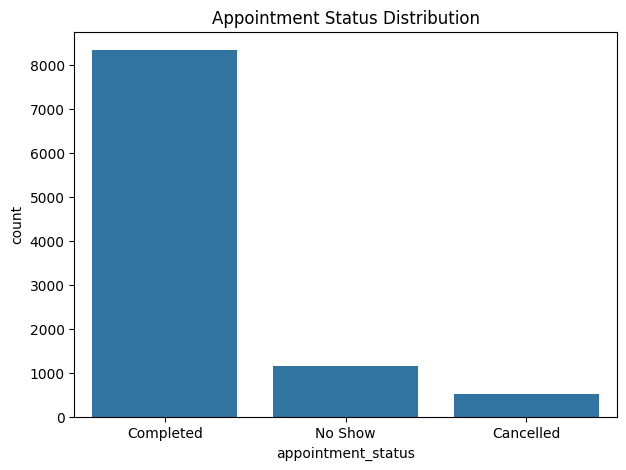

In [118]:
plt.figure(figsize=(7,5))

sns.countplot(x="appointment_status",data=df)

plt.title("Appointment Status Distribution")

plt.show()

In [119]:
numerical_columns=df.select_dtypes(include=['int64','float64']).columns

numerical_columns

Index(['age', 'bmi', 'doctor_experience_years', 'consultation_fee',
       'booking_to_appointment_days', 'waiting_time_minutes',
       'previous_appointments', 'missed_previous_appointments',
       'hospital_rating', 'emergency_case', 'patient_satisfaction_score',
       'medicine_cost', 'test_cost', 'total_bill'],
      dtype='object')

In [120]:
categorical_columns=df.select_dtypes(include='object').columns

categorical_columns

Index(['patient_id', 'gender', 'city', 'chronic_disease', 'appointment_type',
       'department', 'symptoms', 'severity_level', 'insurance',
       'appointment_day', 'appointment_month', 'appointment_status'],
      dtype='object')

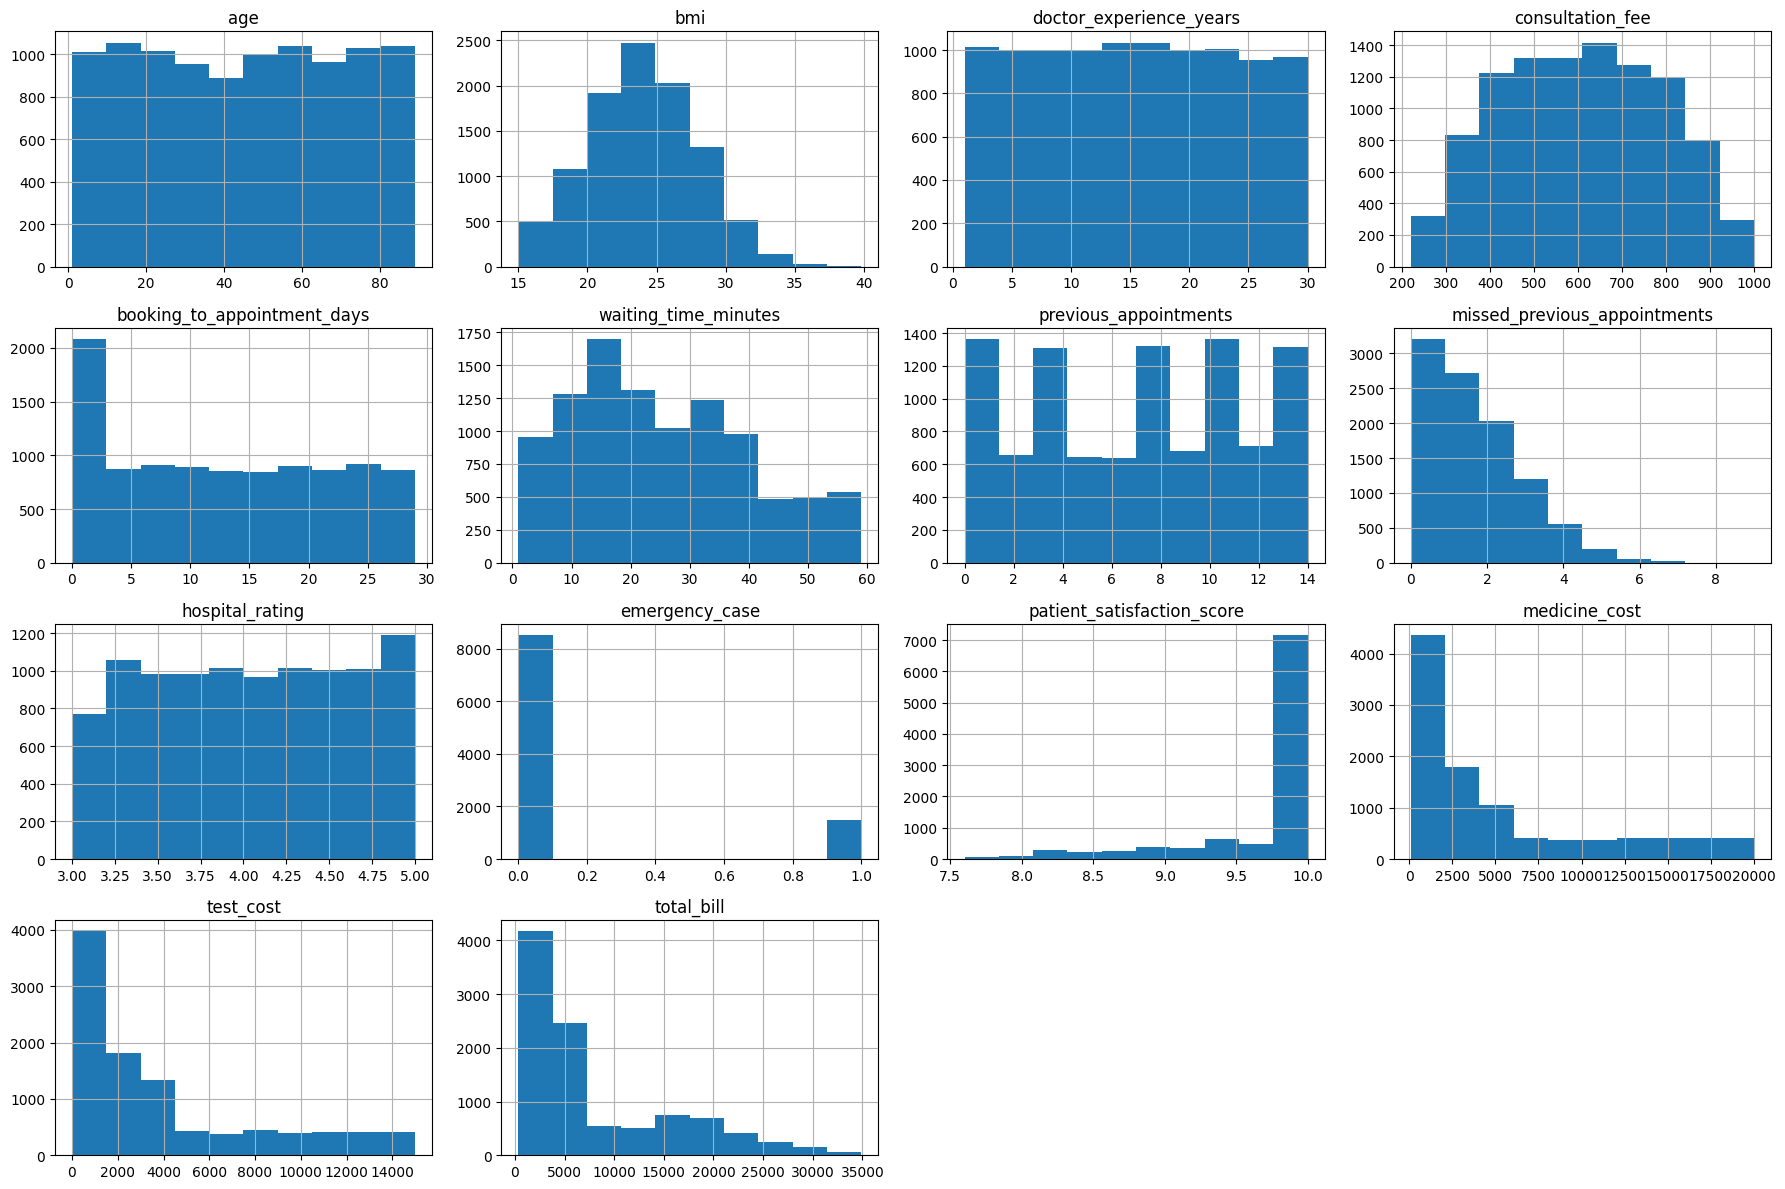

In [121]:
df[numerical_columns].hist(figsize=(18,12))

plt.tight_layout()

plt.show()

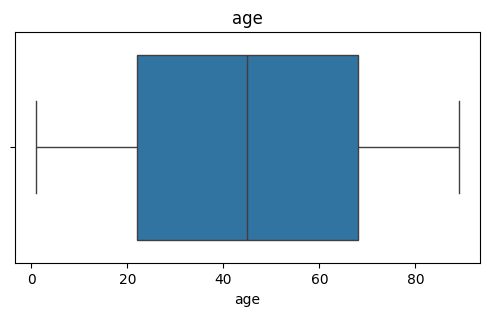

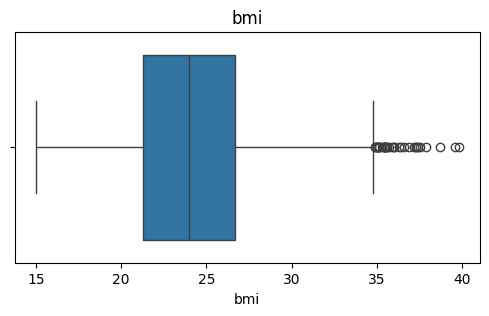

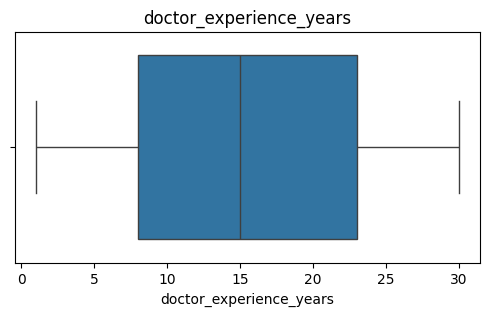

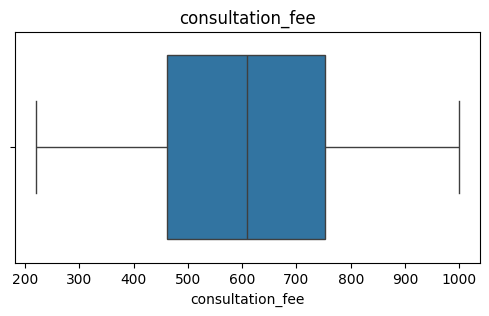

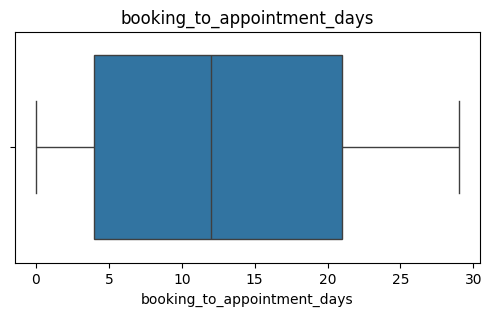

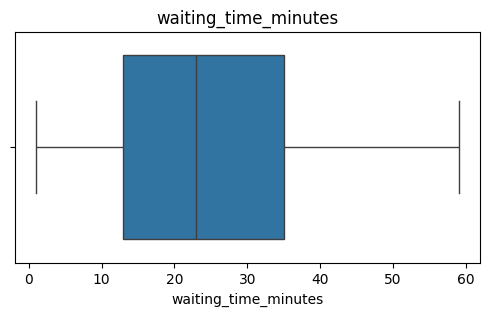

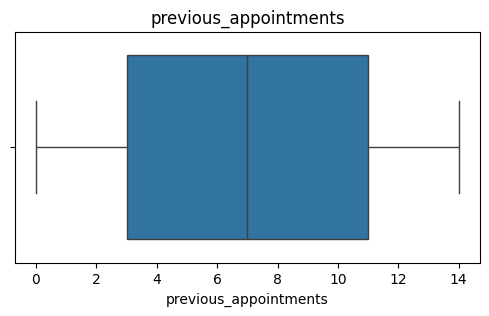

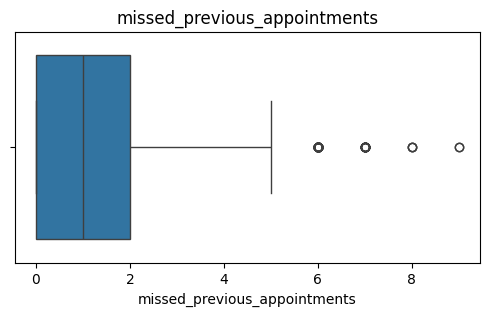

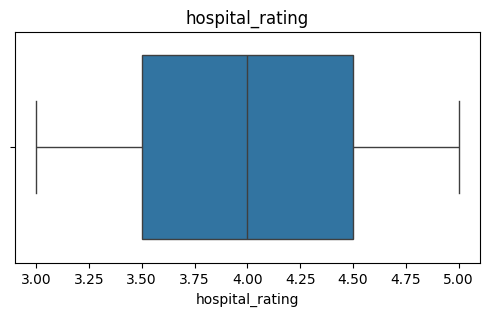

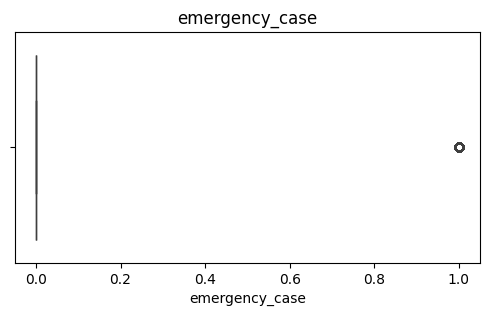

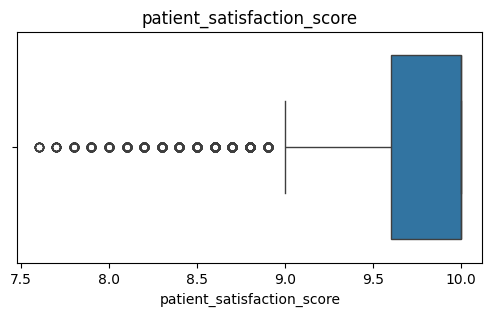

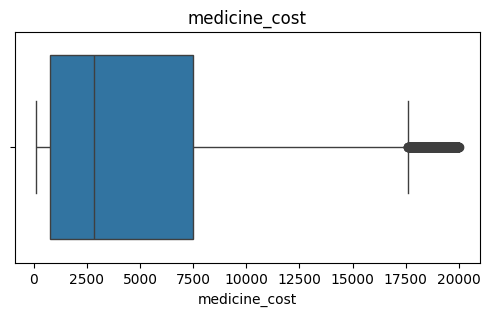

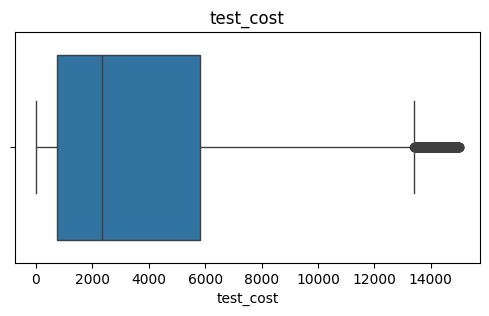

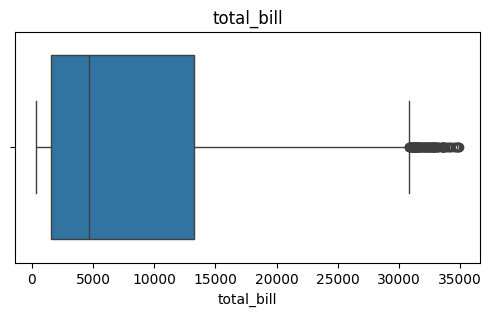

In [122]:
for column in numerical_columns:

    plt.figure(figsize=(6,3))

    sns.boxplot(x=df[column])

    plt.title(column)

    plt.show()

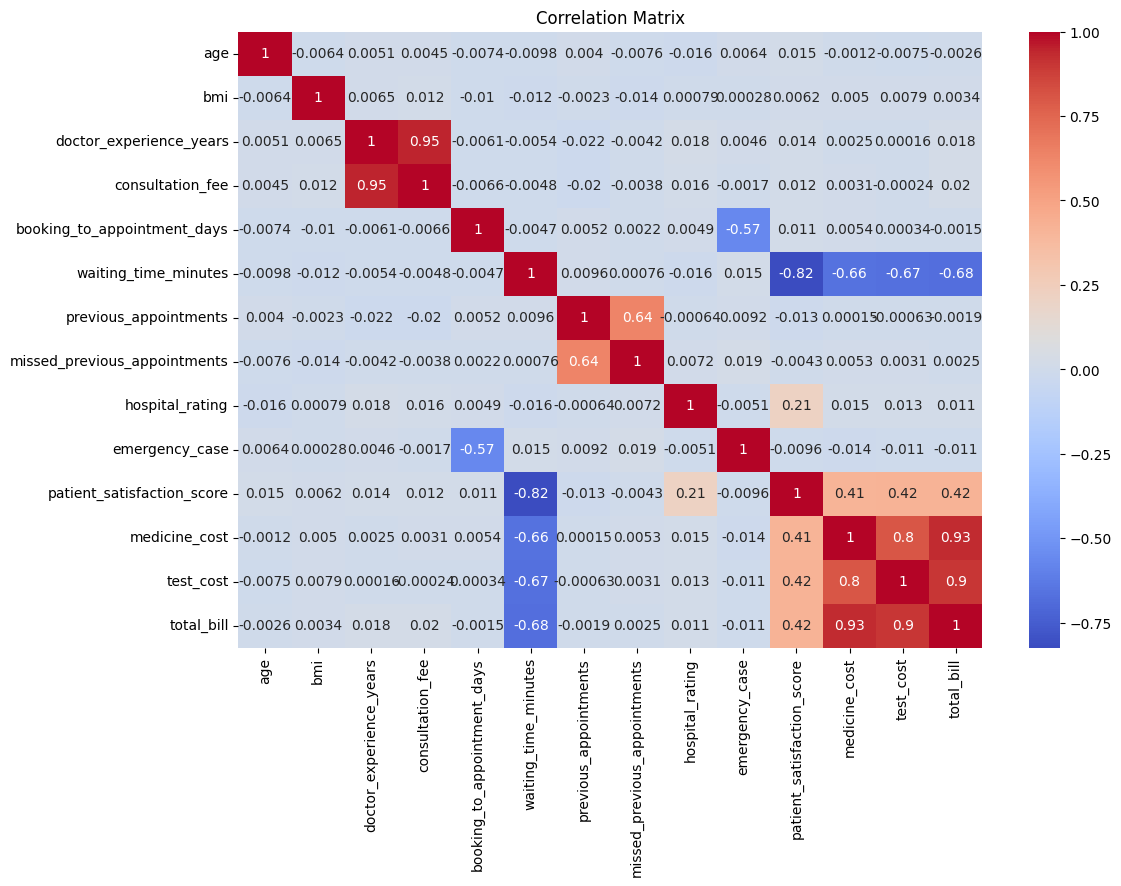

In [123]:
plt.figure(figsize=(12,8))

sns.heatmap(df[numerical_columns].corr(),
            annot=True,
            cmap="coolwarm")

plt.title("Correlation Matrix")

plt.show()

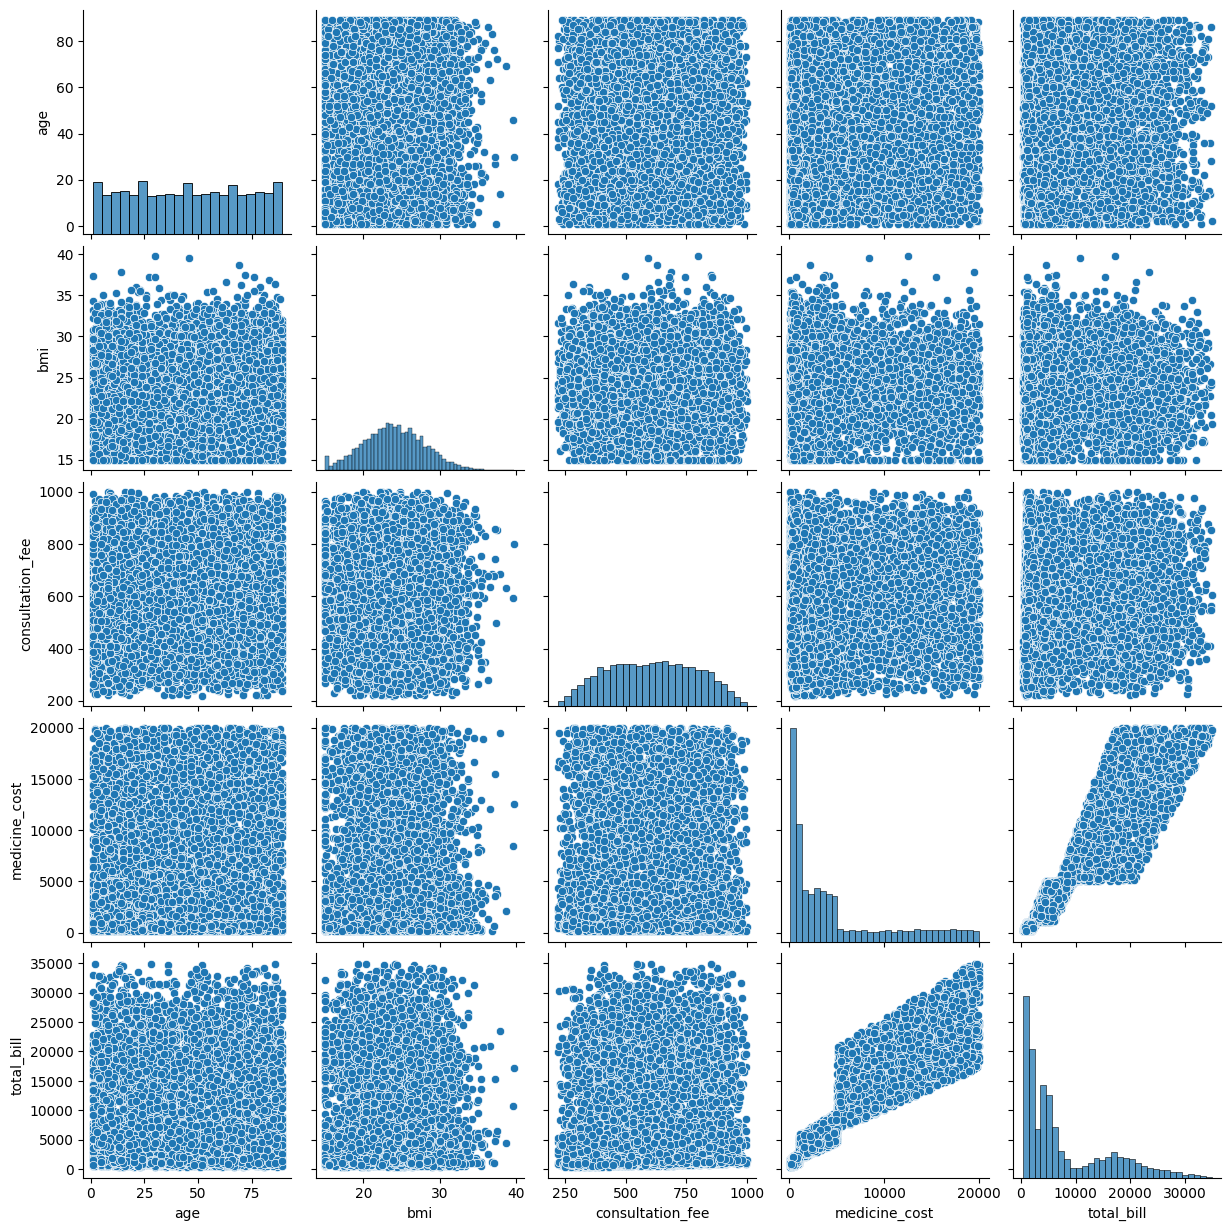

In [124]:
sns.pairplot(df[['age',
                 'bmi',
                 'consultation_fee',
                 'medicine_cost',
                 'total_bill']])

plt.show()

In [125]:
df=df.drop("patient_id",axis=1)

In [126]:
num_cols=df.select_dtypes(include=['int64','float64']).columns

for col in num_cols:

    df[col].fillna(df[col].median(),inplace=True)

In [127]:
cat_cols=df.select_dtypes(include='object').columns

for col in cat_cols:

    df[col].fillna(df[col].mode()[0],inplace=True)

In [128]:
df.isnull().sum()

age                             0
gender                          0
city                            0
bmi                             0
chronic_disease                 0
appointment_type                0
department                      0
symptoms                        0
severity_level                  0
doctor_experience_years         0
consultation_fee                0
insurance                       0
appointment_day                 0
appointment_month               0
booking_to_appointment_days     0
waiting_time_minutes            0
previous_appointments           0
missed_previous_appointments    0
hospital_rating                 0
emergency_case                  0
patient_satisfaction_score      0
medicine_cost                   0
test_cost                       0
total_bill                      0
appointment_status              0
dtype: int64

In [129]:
label_encoders={}

for column in df.select_dtypes(include='object').columns:

    encoder=LabelEncoder()

    df[column]=encoder.fit_transform(df[column])

    label_encoders[column]=encoder

In [130]:
df.head()

,age,gender,city,bmi,chronic_disease,appointment_type,department,symptoms,severity_level,doctor_experience_years,...,waiting_time_minutes,previous_appointments,missed_previous_appointments,hospital_rating,emergency_case,patient_satisfaction_score,medicine_cost,test_cost,total_bill,appointment_status
0,52,1,7,19.6,3,1,6,5,1,19,...,43,7,2,3.0,0,8.6,869,413,1936.0,1
1,21,0,7,25.3,1,1,6,5,1,1,...,44,11,5,3.5,0,8.8,786,875,1356.6,2
2,51,0,1,21.9,1,1,2,8,1,18,...,33,9,0,4.4,0,10.0,466,427,1108.8,2
3,78,0,3,31.7,1,2,8,6,1,17,...,59,13,3,4.1,0,8.1,921,401,1417.5,1
4,62,0,7,24.7,3,1,7,3,1,15,...,42,4,0,3.5,0,8.9,152,216,746.9,1


In [131]:
X=df.drop("appointment_status",axis=1)

y=df["appointment_status"]

In [132]:
X_train,X_test,y_train,y_test=train_test_split(

X,
y,
test_size=0.2,
random_state=42,
stratify=y
)

In [133]:
print(X_train.shape)
print(X_test.shape)

(8000, 24)
(2000, 24)


In [134]:
model=RandomForestClassifier(

n_estimators=300,

max_depth=None,

random_state=42
)

In [135]:
model.fit(X_train,y_train)

,n_estimators,300
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [136]:
y_pred=model.predict(X_test)

In [137]:
accuracy=accuracy_score(y_test,y_pred)

print("Accuracy =",accuracy)

Accuracy = 0.8345


In [138]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.00      0.00      0.00       101
           1       0.83      1.00      0.91      1668
           2       1.00      0.00      0.01       231

    accuracy                           0.83      2000
   macro avg       0.61      0.33      0.31      2000
weighted avg       0.81      0.83      0.76      2000



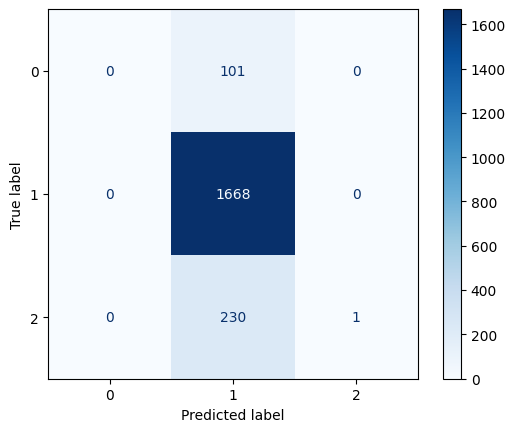

In [139]:
cm=confusion_matrix(y_test,y_pred)

disp=ConfusionMatrixDisplay(cm)

disp.plot(cmap="Blues")

plt.show()

In [140]:
importance=pd.DataFrame({

'Feature':X.columns,

'Importance':model.feature_importances_

})

importance=importance.sort_values(

by='Importance',

ascending=False
)

importance

,Feature,Importance
14,booking_to_appointment_days,0.077310
22,test_cost,0.069839
21,medicine_cost,0.069383
10,consultation_fee,0.068221
23,total_bill,0.067327
3,bmi,0.067249
0,age,0.062731
15,waiting_time_minutes,0.057209
18,hospital_rating,0.052065
9,doctor_experience_years,0.050816


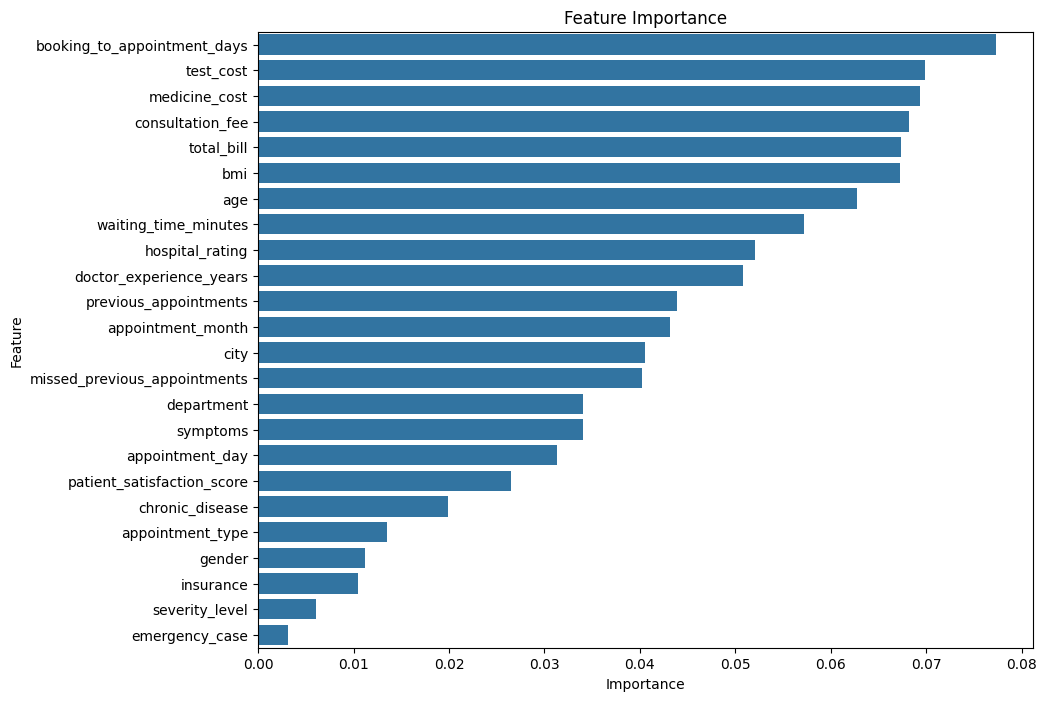

In [141]:
plt.figure(figsize=(10,8))

sns.barplot(data=importance,

x='Importance',

y='Feature')

plt.title("Feature Importance")

plt.show()

In [142]:
joblib.dump(model,"hospital_model.pkl")

print("Model Saved Successfully")

Model Saved Successfully


In [143]:
joblib.dump(label_encoders,"label_encoders.pkl")

print("Encoders Saved Successfully")

Encoders Saved Successfully
